# Trabajo Práctico 2 (TP2) - Parte 1: Preprocesamiento de Datos y Análisis Estadístico Exploratorio

### Machine Learning 1 (23433)
#### Facultad de Ingeniería - Universidad Nacional de Asunción (FIUNA)

---

## Objetivos de la Parte 1
1. Cargar e inspeccionar la estructura del conjunto de datos unificado de rendimiento académico de FIUNA (`reglamento_nuevo_unificado.csv`).
2. Mapear las 27 siglas e intensificaciones curriculares a las 7 carreras principales de la facultad.
3. Aplicar un preprocesamiento de integridad de datos **no destructivo** que preserve el 100% de los 64,295 registros sin eliminar filas.
4. Responder a 6 preguntas estadísticas exploratorias clave para auditar la masa estudiantil, la retención académica y las tasas de aprobación.


In [57]:
# 1. Carga de Librerías Fundamentales
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
pd.set_option('display.max_columns', 25)
pd.set_option('display.width', 1000)

# Carga del Dataset
csv_path = 'reglamento_nuevo_unificado.csv'
if not os.path.exists(csv_path):
    csv_path = os.path.join('..', 'Clase_5', 'reglamento_nuevo_unificado.csv')

df_raw = pd.read_csv(csv_path)
print(f"Dataset cargado exitosamente: {df_raw.shape[0]:,} filas y {df_raw.shape[1]} columnas.")


Dataset cargado exitosamente: 64,295 filas y 29 columnas.


## Ejercicio 1: Mapeo de Intensificaciones Curriculares a Carreras Principales

Completa el diccionario `career_code_mapping` para mapear las 27 siglas del sistema (`CIV-PLS13`, `INT9CONSTR`, `ELE-PLS23`, `INT9SDIGYT`, `MCT-PLS13`, `IND-PLS13`, `CGF-PLS13`, `MEC-PLS13`, `ECA-PLS13`, etc.) a sus 7 carreras principales:
- `Ing. Civil`
- `Ing. Electrónica`
- `Ing. Mecatrónica`
- `Ing. Industrial`
- `Ing. Geográfica`
- `Ing. Mecánica`
- `Ing. Electromecánica`


In [58]:
# TODO: Completar la estructura del diccionario career_code_mapping
career_code_mapping = {
    # === ESCRIBE TU CÓDIGO AQUÍ ===
    'CIV-PLS13': 'Ing. Civil', 'CIV-PLS23': 'Ing. Civil', 'INT9CONSTR': 'Ing. Civil',
    'INT9TRANSP': 'Ing. Civil', 'INT9ORTERR': 'Ing. Civil', 'INT9SANEHI': 'Ing. Civil',
    
    'ELE-PLS13': 'Ing. Electrónica', 'ELE-PLS23': 'Ing. Electrónica',
    'INT9ELECTR': 'Ing. Electrónica', 'INT9SDIGYT': 'Ing. Electrónica',
    
    'MCT-PLS13': 'Ing. Mecatrónica', 'MCT-PLS23': 'Ing. Mecatrónica', 'MCT9-OPT': 'Ing. Mecatrónica',
    
    'IND-PLS13': 'Ing. Industrial', 'IND-PLS23': 'Ing. Industrial',
    'INT9G-ECO': 'Ing. Industrial', 'INT9-PROYT': 'Ing. Industrial',
    
    'CGF-PLS13': 'Ing. Geográfica', 'CGF-PLS23': 'Ing. Geográfica', 'INT9RNYMA': 'Ing. Geográfica',
    
    'MEC-PLS13': 'Ing. Mecánica', 'MEC-PLS23': 'Ing. Mecánica',
    'INT9MECANI': 'Ing. Mecánica', 'MEC9-OPT': 'Ing. Mecánica',
    
    'ECA-PLS13': 'Ing. Electromecánica', 'ECA-PLS23': 'Ing. Electromecánica', 'ECA9-OPT': 'Ing. Electromecánica'
}

df_clean = df_raw.copy()
# TODO: Asignar la nueva columna Carrera_Nombre usando map()
df_clean['Carrera_Nombre'] = df_clean['Cod.Car.Sec'].astype(str).str.strip().map(career_code_mapping)

# Definición del Target Binario (1 para 'S', 0 para 'N')
df_clean = df_clean.dropna(subset=['Aprobado', 'Carrera_Nombre']).copy()
df_clean['Target'] = (df_clean['Aprobado'] == 'S').astype(int)

print(f"Filas tras mapeo de carreras: {len(df_clean):,}")


Filas tras mapeo de carreras: 64,295


## Ejercicio 2: Limpieza Numérica y Generación de Atributos Derivados (Sin Eliminación de Filas)

Convierte los campos numéricos de parciales y evaluaciones a formato float utilizando `pd.to_numeric(..., errors='coerce')` para mantener el 100% de las filas.
Crea las siguientes variables derivadas:
- `Score_Parciales`: Promedio entre el 1er y 2do parcial.
- `Diff_Parciales`: Diferencia ($2^\circ\text{Par} - 1^\circ\text{Par}$).


In [59]:
# TODO: Limpiar y convertir atributos numéricos sin eliminar filas
# === ESCRIBE TU CÓDIGO AQUÍ ===
df_clean['Primer_Par_Clean'] = pd.to_numeric(df_clean['Primer.Par'], errors='coerce')
df_clean['Segundo_Par_Clean'] = pd.to_numeric(df_clean['Segundo.Par'], errors='coerce')
df_clean['Score_Parciales'] = (df_clean['Primer_Par_Clean'].fillna(0) + df_clean['Segundo_Par_Clean'].fillna(0)) / 2.0
df_clean['Diff_Parciales'] = df_clean['Segundo_Par_Clean'].fillna(0) - df_clean['Primer_Par_Clean'].fillna(0)
df_clean['TPLab_Clean'] = pd.to_numeric(df_clean['TPLab.'], errors='coerce')
df_clean['Asis_Clean'] = pd.to_numeric(df_clean['Asis'], errors='coerce')
df_clean['Firma_Clean'] = pd.to_numeric(df_clean['Firma'], errors='coerce')
df_clean['FirmaCalc_Clean'] = pd.to_numeric(df_clean['FirmaCalculada'], errors='coerce')

print(f"Filas preservadas en df_clean: {len(df_clean):,} (100% retención)")


Filas preservadas en df_clean: 64,295 (100% retención)


## Ejercicio 3: Auditoría Estadísticas Exploratoria (6 Preguntas Clave)

Responde a las siguientes 6 preguntas estadísticas utilizando código en Python sobre `df_raw` y `df_clean`:

1. **¿Cuántos estudiantes presentan registros en los tres ciclos del CSV?**
2. **¿Cuántas personas/registros tienen calificación final (`Nota.Final`)?**
3. **¿Cuántos tienen proceso (`FirmaCalculada` / `Firma`)?**
4. **¿Cuál es la tasa de aprobación global y por Carrera?**
5. **¿Cómo se comparan las notas medias del 1er y 2do Parcial según condición final (Aprobado vs No Aprobado)?**
6. **¿Cuál es la tasa de abandono / inasistencia total a parciales?**


# Resultados del Profesor para tener de referencia


# === 3. AUDITORÍA ESTADÍSTICA EXPLORATORIA DE FIUNA ===

1. Estudiantes con registros en los 3 ciclos: 3,532 (74.22% del total)

2. Registros con Nota.Final: 42,720 | Estudiantes únicos: 4,344

3. Registros con FirmaCalculada: 19,407 | Registros con Firma >= 50: 41,715

4. Tasa de Aprobación por Carrera:

| Carrera_Nombre          | Inscritos | Aprobados | Tasa_Aprob_Pct |
|-------------------------|----------:|----------:|---------------:|
| Ing. Civil              | 29392     | 17202     | 58.526130      |
| Ing. Electromecánica    | 1693      | 1150      | 67.926757      |
| Ing. Electrónica        | 11928     | 6638      | 55.650570      |
| Ing. Geográfica         | 4626      | 3275      | 70.795504      |
| Ing. Industrial         | 6416      | 4050      | 63.123441      |
| Ing. Mecatrónica        | 7147      | 4691      | 65.635931      |
| Ing. Mecánica           | 3093      | 1999      | 64.629809      |

5. Promedios de Parciales por Target:

| Target | Primer_Par_Clean | Segundo_Par_Clean |
|-------:|-----------------:|------------------:|
| 0      | 26.163306        | 19.561961         |
| 1      | 63.631252        | 65.528804         |

6. Registros con 0 en ambos parciales: 9,340 (14.53%)

# Mi desarrollo 

## Vista Previa (Repaso de Pandas, Fuera del Contenido del TP)

In [60]:
print(df_raw.shape) # shape: muestra (filas, columnas)
print(list(df_raw.columns)) #columns: imprime las etiquetas 
df_raw.head(3) #head: imprime las primeras 3 filas
df_raw.info() #info: vemos el tipo de variables de cada columna del data frame en cuestion
#especificamente dtypes, no nulos por columna

(64295, 29)
['ALUMNO_ID', 'Cod.Asign', 'Asignatura', 'Cod.Car.Sec', 'Cod.Curso', 'Convocatoria', 'Anho', 'Semestre', 'Doc.Firma', 'Aprobado', 'Anho.Firma', 'Primer.Par', 'Segundo.Par', 'Tercer.Par', 'TPLab.', 'Lab.', 'Proy.', 'Pond.PP', 'Pond.SP', 'Pond.TPLab', 'Pond.Lab', 'Pond.Proy', 'Asis', 'Requisito', 'Firma', 'Primer.Rec', 'Segundo.Rec', 'Nota.Final', 'FirmaCalculada']
<class 'pandas.DataFrame'>
RangeIndex: 64295 entries, 0 to 64294
Data columns (total 29 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   ALUMNO_ID       64295 non-null  str    
 1   Cod.Asign       64295 non-null  int64  
 2   Asignatura      64295 non-null  str    
 3   Cod.Car.Sec     64295 non-null  str    
 4   Cod.Curso       64295 non-null  int64  
 5   Convocatoria    64295 non-null  int64  
 6   Anho            64295 non-null  int64  
 7   Semestre        64295 non-null  int64  
 8   Doc.Firma       64295 non-null  int64  
 9   Aprobado        64295 no

In [61]:
print(df_raw.isna().sum()[lambda s: s > 0]) 
#isna convierte cada celda en True si contiene Nan, si tiene algo convierte en False
#como True = 1 y False = 0, al sumar por columnas tenemos la cantida de valores faltantes
'''
resulta que df_raw.isna().sum() es del tipo Series, y se puede filtrar con una mascara booleana 
la mascara booleana labda s: s > 0, mira s y devuelve True a elementos que sean mayor a 0
pero la forma en la que se aplica la mascara es algo como s=f_raw.isna().sum(), mask = [lambda s: s > 0]) 
que en conjunto funciona como un selector (para true) y descartador (para false) de posiciones
'''

# Columnas constantes: no aportan información al modelo
constantes = [c for c in df_raw.columns if df_raw[c].nunique() <= 1]
'''
Aqui mezclamos varios conceptos,  listas por compresion 
[operacion(c) para c en lista] (se agraga a la nueva lista)
la sintaxis basica es para [c para c en la lista si (condicion se cumple), agrega a la lista]
c para c en la lista que contiene los nombres de todas las columnas del data frame, 
si la cantidad de valores distintos 
(nunique devuelve la cantidad de valores distintos por columna, además devuelve 1 para un unico valor repetido,
0 para todos los valores son Nand) 
de la columna actual df_raw[c] es menor o igual a 1
es decir construimos la lista que tiene como elementos las columnas que tienen valores iguales
'''

print("Constantes:", constantes)     # ['Tercer.Par', 'Pond.Proy', 'Segundo.Rec'] -> todas en 0, etiquetas o nombres de la columnas constantes

# Duplicados
print("Filas idénticas:", df_raw.duplicated().sum()) 
#duplicated: nos da True o False en cada elemento, dependiendo si es duplicado (True) o si es unico (False)
print("Dup. por alumno+materia+ciclo:",
      df_raw.duplicated(subset=['ALUMNO_ID','Cod.Asign','Anho','Semestre']).sum())   

      #subset es un parametro de duplicate, que le indica cuales seran las unicas columnas a considerar para determinar si la fila es o no duplicada



# Granularidad
print("Alumnos únicos:", df_raw['ALUMNO_ID'].nunique())      # 4,759
#cantidad de alumnos únicos (no repetidos) en la columna ALUMNO_ID
print("Asignaturas únicas:", df_raw['Cod.Asign'].nunique())  # 408
#cantidad de asignaturas unicas en la columna Cod.Asign

Nota.Final        21575
FirmaCalculada    44888
dtype: int64
Constantes: ['Tercer.Par', 'Pond.Proy', 'Segundo.Rec']
Filas idénticas: 0
Dup. por alumno+materia+ciclo: 2
Alumnos únicos: 4759
Asignaturas únicas: 408


In [62]:
s = df_raw['Cod.Car.Sec'] 
#observacion, cabe destacar que esta es una serie asociada, no es una copia independiente garantizada por pandas
#solo se utiliza cuando quieres analizar/consultar la columna de manera independiente, si se desea una copia
#agregar el .copy() correspondiente

print(repr(s.unique()[:3]))
# repr conviente a cadena pero de la expresion de la syntaxis, en este caso de los primeros 3 valores unicos de s (s.unique()[:3])
print("nunique:", s.nunique())
#imprime la cantidad de valores unicos de s (no repetidos)

siglas_csv = set(s.astype(str).str.strip().unique())
#set conjunto de elementos unicos (no ordenados), mutable
#s.astype convierte todos los valores de s a str 
#.str permite aplicar metodos str de pyton a todos los elementos de la serie
#strip elimine espacios al inicio y al final
#unique obtiene los elementos que aparecen solo una vez (elimina duplicados)

faltantes = siglas_csv - set(career_code_mapping.keys()) 
#career_code_mapping.keys() obtiene las clabes del diccionario career_code_mapping
sobrantes = set(career_code_mapping.keys()) - siglas_csv
# - es una diferencia de conjuntos 
print("No contempladas en el diccionario:", faltantes)   # set()  -> OK
print("En el diccionario pero no en el CSV:", sobrantes)  # set()  -> OK
# con set() vacio confirmamos que todo está bien

print(s.astype(str).str.strip().value_counts())

<StringArray>
['CGF-PLS13 ', 'ELE-PLS13 ', 'CIV-PLS13 ']
Length: 3, dtype: str
nunique: 27
No contempladas en el diccionario: set()
En el diccionario pero no en el CSV: set()
Cod.Car.Sec
CIV-PLS13     13891
CIV-PLS23     12988
ELE-PLS23      5878
ELE-PLS13      5412
MCT-PLS13      3884
IND-PLS13      3367
CGF-PLS13      3244
MCT-PLS23      2887
IND-PLS23      2678
INT9CONSTR     1861
MEC-PLS13      1422
CGF-PLS23      1294
MEC-PLS23       918
ECA-PLS13       873
ECA-PLS23       768
INT9MECANI      522
INT9ELECTR      506
MCT9-OPT        376
INT9TRANSP      344
INT9G-ECO       235
MEC9-OPT        231
INT9ORTERR      214
INT9-PROYT      136
INT9SDIGYT      132
INT9SANEHI       94
INT9RNYMA        88
ECA9-OPT         52
Name: count, dtype: int64


In [63]:
df_raw[['Primer.Par','Segundo.Par','TPLab.','Asis','Firma','FirmaCalculada']].describe() #Descripcion Estadistica de las columnas indicadas
print(df_raw['Nota.Final'].value_counts(dropna=False).head(10)) #cuenta los 10 valores mas contados en nota final, incluyendo Nan (gracias a dropna=False)
#head ordena por frecuencia de forma descendente de forma predeterminada

print(df_raw['Asis'].value_counts()) #cuenta los valores de asistencia que aprecen (ignora Nan)
print("Firma negativa:", (df_raw['Firma'] < 0).sum()) #Cantidad de Firmas negativas
print(pd.crosstab(df_raw['Semestre'], df_raw['FirmaCalculada'].isna())) #crosstab da una table de contingencia, firma calculada (true o false) por semeste
#indicando la cantidad correspondiente a true y false en ese semestre

Nota.Final
NaN     21575
1F-4     9767
1F-5     6966
1F-3     5374
1F-2     4826
2F-2     3362
2F-4     2589
2F-3     2375
2F-1     2210
2F-5     1919
Name: count, dtype: int64
Asis
1    59195
2     2781
0     2319
Name: count, dtype: int64
Firma negativa: 232
FirmaCalculada  False  True 
Semestre                    
1               19407      0
2                   0  44888


In [64]:
d = df_raw[df_raw['Nota.Final'].notna()].copy()
#serie booleana, True != Nan, Nan = False
#.copy hace una copia independiente 

d['ultima_nota'] = d['Nota.Final'].str.split(',').str[-1].str.split('-').str[-1].astype(int)
#str.split(',') separa texto por ,
#str[-1] toma ultimo elemento de cara lista 
#.astype(int) convierte a entero 
print(pd.crosstab(d['ultima_nota'], d['Aprobado'])) #tabla de contingencia

Aprobado        N      S
ultima_nota             
1            3631     58
2              40   9242
3              30   8157
4              10  12564
5               4   8984


In [65]:
# Paso 1 (Ej.1, celda 3) — copia + mapeo de carrera
df_clean = df_raw.copy() #crea un dataframe nuevo, independiente de df?raw
df_clean['Carrera_Nombre'] = (df_clean['Cod.Car.Sec']
                              .astype(str).str.strip()      # el strip es obligatorio
                              .map(career_code_mapping))

                              #Genera la columna Carrera_Nombre
                              # al construir de manera: obtiene columna Cod.Car.Sec, convierte a str, eliminar espacios al inicio y al final, con map,
                              # asigna la clave valor correspondiente a esta nueva columna (devuelve el valor asociado)



# Paso 2 (Ej.1, celda 3) — filtrado + target binario
df_clean = df_clean.dropna(subset=['Aprobado', 'Carrera_Nombre']).copy()
df_clean['Target'] = (df_clean['Aprobado'] == 'S').astype(int)

# Paso 3 (Ej.2, celda 5) — columnas numéricas limpias y derivadas
df_clean['Primer_Par_Clean']  = pd.to_numeric(df_clean['Primer.Par'],     errors='coerce')
df_clean['Segundo_Par_Clean'] = pd.to_numeric(df_clean['Segundo.Par'],    errors='coerce')
df_clean['TPLab_Clean']       = pd.to_numeric(df_clean['TPLab.'],         errors='coerce')
df_clean['Asis_Clean']        = pd.to_numeric(df_clean['Asis'],           errors='coerce')
df_clean['Firma_Clean']       = pd.to_numeric(df_clean['Firma'],          errors='coerce')
df_clean['FirmaCalc_Clean']   = pd.to_numeric(df_clean['FirmaCalculada'], errors='coerce')

df_clean['Score_Parciales'] = (df_clean['Primer_Par_Clean'].fillna(0)
                             + df_clean['Segundo_Par_Clean'].fillna(0)) / 2.0
df_clean['Diff_Parciales']  = (df_clean['Segundo_Par_Clean'].fillna(0)
                             - df_clean['Primer_Par_Clean'].fillna(0))

In [66]:
# 1) El centinela -1 de Firma no es un valor válido
df_clean.loc[df_clean['Firma_Clean'] < 0, 'Firma_Clean'] = np.nan

# 2) Firma unificada: FirmaCalculada donde existe (Sem.1), Firma como respaldo (Sem.2)
df_clean['Firma_Final'] = df_clean['FirmaCalc_Clean'].fillna(df_clean['Firma_Clean'])

# 3) La columna Ciclo que el CSV no trae
df_clean['Ciclo'] = df_clean['Anho'].astype(str) + '-S' + df_clean['Semestre'].astype(str)

In [67]:
print(f"df_raw:   {len(df_raw):,} filas")
print(f"df_clean: {len(df_clean):,} filas  (perdidas: {len(df_raw)-len(df_clean):,})")
# df_raw:   64,295 | df_clean: 64,295 | perdidas: 0

df_raw:   64,295 filas
df_clean: 64,295 filas  (perdidas: 0)


# Contenido del TP

## 1. **¿Cuántos estudiantes presentan registros en los tres ciclos del CSV?**

Ciclos: ['2024-S2', '2025-S1', '2025-S2']
Alumnos únicos: 4,759
Presentes en los 3 ciclos: 3,532 (74.22%)
Ciclo
1     718
2     509
3    3532
Name: count, dtype: int64


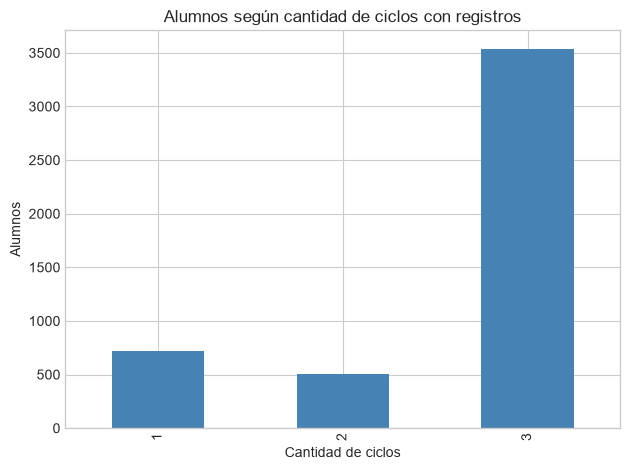

In [68]:
df_clean['Ciclo'] = df_clean['Anho'].astype(str) + '-S' + df_clean['Semestre'].astype(str)
print("Ciclos:", sorted(df_clean['Ciclo'].unique()))   # ['2024-S2', '2025-S1', '2025-S2']

ciclos_por_alumno = df_clean.groupby('ALUMNO_ID')['Ciclo'].nunique()
en_los_3 = (ciclos_por_alumno == 3).sum()

print(f"Alumnos únicos: {ciclos_por_alumno.size:,}")
print(f"Presentes en los 3 ciclos: {en_los_3:,} ({en_los_3/ciclos_por_alumno.size:.2%})")
print(ciclos_por_alumno.value_counts().sort_index())

ciclos_por_alumno.value_counts().sort_index().plot(
    kind='bar', color='steelblue', title='Alumnos según cantidad de ciclos con registros')
plt.xlabel('Cantidad de ciclos'); plt.ylabel('Alumnos'); plt.tight_layout(); plt.show()

## 2. **¿Cuántas personas/registros tienen calificación final (`Nota.Final`)?**

In [69]:
tiene_final = df_clean['Nota.Final'].notna()

print(f"Registros con Nota.Final: {tiene_final.sum():,} de {len(df_clean):,} ({tiene_final.mean():.2%})")
print(f"Personas distintas con al menos un final: {df_clean.loc[tiene_final,'ALUMNO_ID'].nunique():,}")

# Bonus: cuántos finales rindió cada registro (los códigos se separan por coma)
n_finales = df_clean['Nota.Final'].fillna('').str.count('F-')
print(n_finales.value_counts().sort_index())

Registros con Nota.Final: 42,720 de 64,295 (66.44%)
Personas distintas con al menos un final: 4,344
Nota.Final
0    21575
1    40008
2     2666
3       46
Name: count, dtype: int64


## 3. **¿Cuántos tienen proceso (`FirmaCalculada` / `Firma`)?**

In [70]:
firma = df_clean['FirmaCalc_Clean'].fillna(df_clean['Firma_Clean'])   # o df_clean['Firma_Final']
tiene_proceso = firma >= 50

print(f"Registros con firma >= 50: {tiene_proceso.sum():,} ({tiene_proceso.mean():.2%})")
print(f"Personas distintas con proceso: {df_clean.loc[tiene_proceso,'ALUMNO_ID'].nunique():,}")
print(f"Registros sin dato de firma: {firma.isna().sum():,}")
print(f"Centinelas -1 detectados en Firma: {(df_clean['Firma'] == -1).sum():,}")

Registros con firma >= 50: 40,034 (62.27%)
Personas distintas con proceso: 4,362
Registros sin dato de firma: 154
Centinelas -1 detectados en Firma: 232


## 4. **¿Cuál es la tasa de aprobación global y por Carrera?**

Tasa de aprobación global: 60.67%


,Registros,Aprobados,Tasa
Carrera_Nombre,,,
Ing. Geográfica,4626,3275,70.80
Ing. Electromecánica,1693,1150,67.93
Ing. Mecatrónica,7147,4691,65.64
Ing. Mecánica,3093,1999,64.63
Ing. Industrial,6416,4050,63.12
Ing. Civil,29392,17202,58.53
Ing. Electrónica,11928,6638,55.65


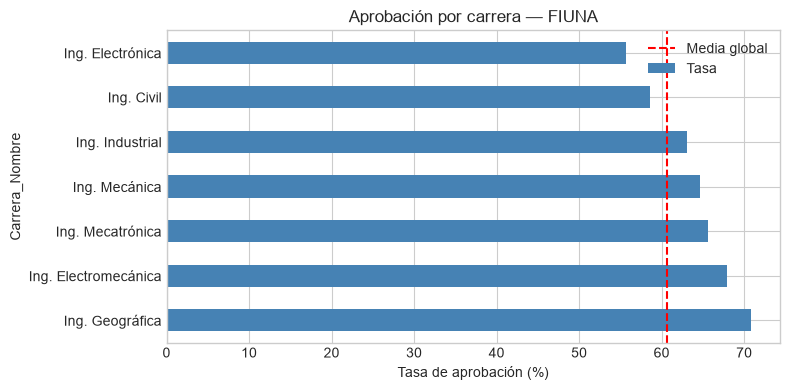

In [71]:
print(f"Tasa de aprobación global: {df_clean['Target'].mean():.2%}")

tasa = (df_clean.groupby('Carrera_Nombre')['Target']
        .agg(Registros='count', Aprobados='sum', Tasa='mean')
        .sort_values('Tasa', ascending=False))
tasa['Tasa'] = (tasa['Tasa'] * 100).round(2)
display(tasa)

ax = tasa['Tasa'].plot(kind='barh', figsize=(8,4), color='steelblue')
ax.axvline(df_clean['Target'].mean()*100, ls='--', c='r', label='Media global')
ax.set_xlabel('Tasa de aprobación (%)'); ax.set_title('Aprobación por carrera — FIUNA')
ax.legend(); plt.tight_layout(); plt.show()

## 5. **¿Cómo se comparan las notas medias del 1er y 2do Parcial según condición final (Aprobado vs No Aprobado)?**

Primer_Par_Clean                      Segundo_Par_Clean                     
                            mean    std median  count              mean    std median  count
No aprobado (0)            26.16  24.49   23.0  25290             19.56  23.94    6.0  25290
Aprobado (1)               63.63  26.80   68.0  39005             65.53  27.58   71.0  39005

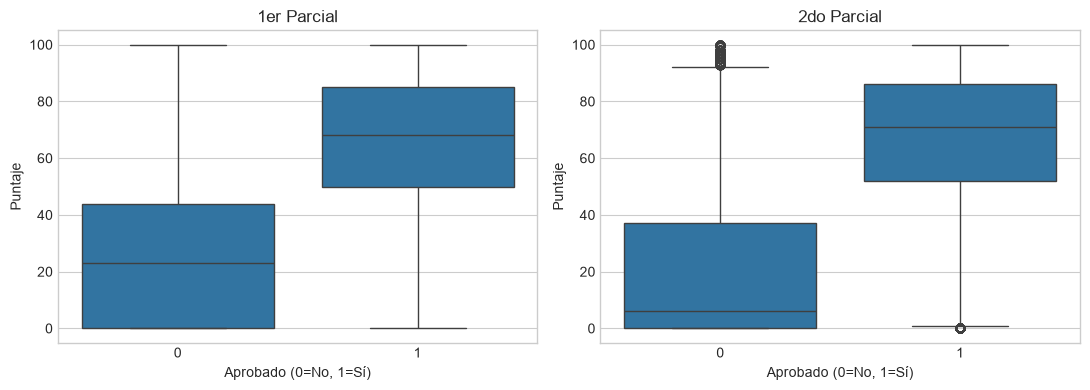

In [72]:
comp = (df_clean.groupby('Target')[['Primer_Par_Clean','Segundo_Par_Clean']]
        .agg(['mean','std','median','count']).round(2))
comp.index = ['No aprobado (0)', 'Aprobado (1)']
display(comp)

fig, axes = plt.subplots(1, 2, figsize=(11,4))
for ax, col, t in zip(axes, ['Primer_Par_Clean','Segundo_Par_Clean'], ['1er Parcial','2do Parcial']):
    sns.boxplot(data=df_clean, x='Target', y=col, ax=ax)
    ax.set_title(t); ax.set_xlabel('Aprobado (0=No, 1=Sí)'); ax.set_ylabel('Puntaje')
plt.tight_layout(); plt.show()

## 6. **¿Cuál es la tasa de abandono / inasistencia total a parciales?**


In [73]:
p1, p2 = df_clean['Primer_Par_Clean'], df_clean['Segundo_Par_Clean']
abandono = (p1.isna() | (p1 == 0)) & (p2.isna() | (p2 == 0))

print(f"Tasa de abandono/inasistencia total: {abandono.mean():.2%} ({abandono.sum():,} registros)")
print(f"  - cero en ambos parciales: {((p1==0) & (p2==0)).sum():,}")
print(f"  - ausencia (NaN) en ambos: {(p1.isna() & p2.isna()).sum():,}")
print(f"Solo 1er parcial en 0: {(p1==0).sum():,} | solo 2do en 0: {(p2==0).sum():,}")

por_carrera = (df_clean.assign(Abandono=abandono)
               .groupby('Carrera_Nombre')['Abandono'].mean().mul(100).round(2)
               .sort_values(ascending=False))
display(por_carrera)
print(pd.crosstab(abandono, df_clean['Target'], rownames=['Abandono'], colnames=['Target']))

Tasa de abandono/inasistencia total: 14.53% (9,340 registros)
  - cero en ambos parciales: 9,340
  - ausencia (NaN) en ambos: 0
Solo 1er parcial en 0: 10,259 | solo 2do en 0: 15,132


Carrera_Nombre
Ing. Mecánica           16.00
Ing. Mecatrónica        15.92
Ing. Electrónica        15.57
Ing. Civil              14.41
Ing. Electromecánica    13.53
Ing. Geográfica         12.75
Ing. Industrial         12.39
Name: Abandono, dtype: float64

Target        0      1
Abandono              
False     18269  36686
True       7021   2319


## Resultados Finales

In [74]:
print("=== 3. AUDITORÍA ESTADÍSTICA EXPLORATORIA DE FIUNA ===")

# 1. Continuidad en los 3 ciclos
df_clean['Ciclo'] = df_clean['Anho'].astype(str) + '-S' + df_clean['Semestre'].astype(str)
cpa = df_clean.groupby('ALUMNO_ID')['Ciclo'].nunique()
#Divide las filas en grupos según uno o más valores y luego permite hacer cálculos sobre cada grupo
en3 = (cpa == 3).sum()
print(f"1. Estudiantes con registros en los 3 ciclos: {en3:,} ({en3/cpa.size:.2%} del total)")

# 2. Calificación final
tf = df_clean['Nota.Final'].notna()
print(f"2. Registros con Nota.Final: {tf.sum():,} | Estudiantes únicos: {df_clean.loc[tf,'ALUMNO_ID'].nunique():,}")

# 3. Proceso / firma
print(f"3. Registros con FirmaCalculada: {df_clean['FirmaCalc_Clean'].notna().sum():,} "
      f"| Registros con Firma >= 50: {(df_clean['Firma_Clean'] >= 50).sum():,}")

# 4. Aprobación por carrera
print("4. Tasa de Aprobación por Carrera:")
tasa = df_clean.groupby('Carrera_Nombre').agg(
    Inscritos=('Target','count'), Aprobados=('Target','sum'))
tasa['Tasa_Aprob_Pct'] = tasa['Aprobados'] / tasa['Inscritos'] * 100
print(tasa)

# 5. Parciales por condición
print("5. Promedios de Parciales por Target:")
print(df_clean.groupby('Target')[['Primer_Par_Clean','Segundo_Par_Clean']].mean())

# 6. Abandono
ab = (df_clean['Primer_Par_Clean'] == 0) & (df_clean['Segundo_Par_Clean'] == 0)
print(f"6. Registros con 0 en ambos parciales: {ab.sum():,} ({ab.mean():.2%})")

=== 3. AUDITORÍA ESTADÍSTICA EXPLORATORIA DE FIUNA ===
1. Estudiantes con registros en los 3 ciclos: 3,532 (74.22% del total)
2. Registros con Nota.Final: 42,720 | Estudiantes únicos: 4,344
3. Registros con FirmaCalculada: 19,407 | Registros con Firma >= 50: 41,715
4. Tasa de Aprobación por Carrera:
                      Inscritos  Aprobados  Tasa_Aprob_Pct
Carrera_Nombre                                            
Ing. Civil                29392      17202       58.526130
Ing. Electromecánica       1693       1150       67.926757
Ing. Electrónica          11928       6638       55.650570
Ing. Geográfica            4626       3275       70.795504
Ing. Industrial            6416       4050       63.123441
Ing. Mecatrónica           7147       4691       65.635931
Ing. Mecánica              3093       1999       64.629809
5. Promedios de Parciales por Target:
        Primer_Par_Clean  Segundo_Par_Clean
Target                                     
0              26.163306          19.56196